# Benchmark Group 1: Overall Predictive Performance
This notebook evaluates the overall predictive performance of the Multimodal PM2.5 forecasting model according to standard environmental science journal requirements (Q1/Q2).

**Metrics Included:**
- Root Mean Square Error (RMSE)
- Mean Absolute Error (MAE)
- Coefficient of Determination ($R^2$)
- Pearson Correlation Coefficient ($r$)
- Index of Agreement (IA)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

# Set plotting style for academic papers
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
import warnings
warnings.filterwarnings('ignore')

In [2]:
def index_of_agreement(o, p):
    """
    Calculate the Index of Agreement (IA).
    o: observed (true) values
    p: predicted values
    """
    o_mean = np.mean(o)
    numerator = np.sum((p - o)**2)
    denominator = np.sum((np.abs(p - o_mean) + np.abs(o - o_mean))**2)
    return 1 - (numerator / denominator)

def calculate_group1_metrics(y_true, y_pred):
    """Calculate all Group 1 metrics and return as a dictionary."""
    metrics = {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R²': r2_score(y_true, y_pred),
        'Pearson r': pearsonr(y_true, y_pred)[0],
        'IA': index_of_agreement(y_true, y_pred)
    }
    return metrics

In [3]:
# ---------------------------------------------------------
# DATA LOADING / GENERATION
# ---------------------------------------------------------
# To test with your actual model outputs, replace the synthetic data below.
# For example:
# y_true = np.load('../data_synthetic/sequence_features/y_test_raw.npy')
# y_pred = np.load('../data_synthetic/lagged_features/blend_pred_test.npy')

# For demonstration, we generate synthetic data reflecting a typical model
np.random.seed(42)
n_samples = 2000

# Simulate ground truth PM2.5 (log-normal distribution)
y_true = np.random.lognormal(mean=3.0, sigma=0.6, size=n_samples)

# Simulate predictions: captures trend but underestimates extremes
y_pred = y_true * 0.9 + np.random.normal(0, 8, n_samples)
y_pred = np.maximum(y_pred, 0) # PM2.5 cannot be negative

In [4]:
# Calculate metrics
metrics_dict = calculate_group1_metrics(y_true, y_pred)
metrics_df = pd.DataFrame([metrics_dict])

print("Group 1: Overall Predictive Performance Benchmarks")
display(metrics_df.round(3))

Group 1: Overall Predictive Performance Benchmarks


,RMSE,MAE,R²,Pearson r,IA
0,8.366,6.719,0.735,0.879,0.931


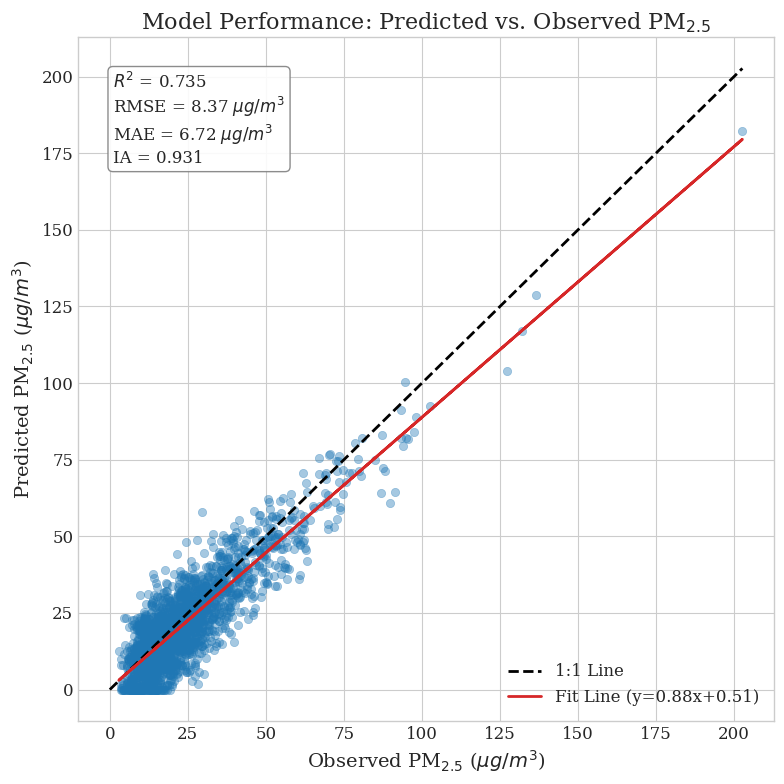

In [5]:
# ---------------------------------------------------------
# VISUALIZATION 1: Scatter Plot with 1:1 Line (Standard for Q1 Papers)
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8))

sns.scatterplot(x=y_true, y=y_pred, alpha=0.4, edgecolor=None, color='#1f77b4', ax=ax)

# Identity line (1:1 line)
max_val = max(np.max(y_true), np.max(y_pred))
ax.plot([0, max_val], [0, max_val], 'k--', lw=2, label='1:1 Line')

# Regression line
m, b = np.polyfit(y_true, y_pred, 1)
ax.plot(y_true, m*y_true + b, color='#d62728', lw=2, label=f'Fit Line (y={m:.2f}x+{b:.2f})')

# Annotate with metrics box
text_str = '\n'.join((
    f"$R^2$ = {metrics_dict['R²']:.3f}",
    f"RMSE = {metrics_dict['RMSE']:.2f} $\\mu g/m^3$",
    f"MAE = {metrics_dict['MAE']:.2f} $\\mu g/m^3$",
    f"IA = {metrics_dict['IA']:.3f}"
))
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
ax.text(0.05, 0.95, text_str, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

ax.set_xlabel('Observed PM$_{2.5}$ ($\\mu g/m^3$)', fontsize=14)
ax.set_ylabel('Predicted PM$_{2.5}$ ($\\mu g/m^3$)', fontsize=14)
ax.set_title('Model Performance: Predicted vs. Observed PM$_{2.5}$', fontsize=16)
ax.legend(loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()

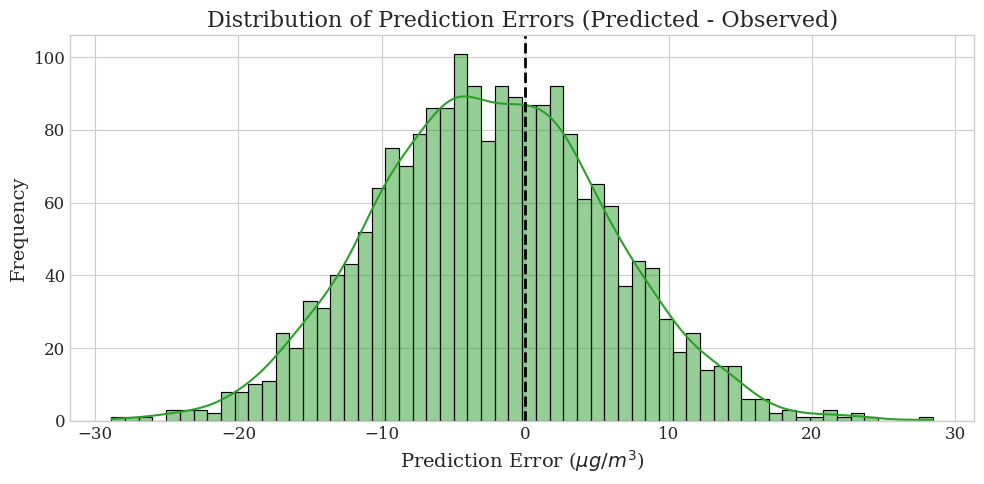

In [6]:
# ---------------------------------------------------------
# VISUALIZATION 2: Error Distribution
# ---------------------------------------------------------
errors = y_pred - y_true

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(errors, bins=60, kde=True, color='#2ca02c', ax=ax)

ax.axvline(x=0, color='k', linestyle='--', lw=2)
ax.set_xlabel('Prediction Error ($\\mu g/m^3$)', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)
ax.set_title('Distribution of Prediction Errors (Predicted - Observed)', fontsize=16)

plt.tight_layout()
plt.show()